# Data Exploration Notebook

---
embed-resources: true
---

## Methods

In [105]:
import sys
from pathlib import Path

# Get project root (one level above notebooks/)
PROJECT_ROOT = Path().resolve().parent

# Add root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
# imports
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Date & Time Handling
from datetime import datetime

# Data imports
from src.data_loader import (
    load_datathon_data,
    load_forecast_data,
    load_processed_data
)

# Utility imports
from src.utils import (
    prepare_daily_data,
    prepare_intraday_data,
    prepare_interval_data,
    fill_missing,
    add_lag_features,
    add_rolling_features,
    add_interaction_features,
    add_trend_features,
    run_validation_checks,
    print_validation_summary
)

### Data

In [106]:
# load data
data = load_datathon_data()

daily_df = data["daily"].copy()
interval_df = data["interval"].copy()
staffing_df = data["staffing"].copy()

df_forecast = load_forecast_data()
daily_by_client = data["daily_by_client"]
interval_by_client = data["interval_by_client"]

print(daily_df.head())
print(interval_df.head())
print(staffing_df.head())

           Date  Call Volume     CCT  Service Level  Abandon Rate client  \
0  01/01/24 Mon       2147.0  302.45         0.9855        0.0037      A   
1  01/02/24 Tue       7458.0  349.22         0.5213        0.1136      A   
2  01/03/24 Wed       6882.0  331.07         0.7046        0.0432      A   
3  01/04/24 Thu       6208.0  341.80         0.7200        0.0403      A   
4  01/05/24 Fri       6190.0  334.56         0.8063        0.0291      A   

  source_sheet  
0    A - Daily  
1    A - Daily  
2    A - Daily  
3    A - Daily  
4    A - Daily  
   Month  Day  Interval  Service Level  Call Volume  Abandoned Calls  \
0  April    1  00:00:00            1.0          5.0              0.0   
1  April    1  00:30:00            1.0          5.0              0.0   
2  April    1  01:00:00            1.0          4.0              0.0   
3  April    1  01:30:00            1.0          3.0              0.0   
4  April    1  02:00:00            1.0          1.0              0.0   

   Aband

#### Data Cleaning

In [107]:
# =========================================================
# Initial cleaning
# =========================================================
daily_df = prepare_daily_data(daily_df)
interval_df = prepare_interval_data(interval_df)
df_forecast = prepare_intraday_data(df_forecast)

# =========================================================
# Missing values
# =========================================================
daily_df = fill_missing(daily_df, group_col="client")
interval_df = fill_missing(interval_df, group_col="client")
df_forecast = fill_missing(df_forecast)

# =========================================================
# Feature engineering: daily
# =========================================================
daily_df = add_lag_features(daily_df, "Call Volume", group_col="client", sort_col="Date")
daily_df = add_rolling_features(daily_df, "Call Volume", group_col="client", sort_col="Date")
daily_df = add_interaction_features(daily_df)
daily_df = add_trend_features(daily_df, group_col="client")

# =========================================================
# Feature engineering: interval
# =========================================================
# replace "Call Volume" below if your interval target column is named differently
interval_df = add_lag_features(interval_df, "Call Volume", group_col="client", sort_col="datetime")
interval_df = add_rolling_features(interval_df, "Call Volume", group_col="client", sort_col="datetime")
interval_df = add_interaction_features(interval_df)
interval_df = add_trend_features(interval_df, group_col="client")


### Summary Statistics

In [108]:
# =========================================
# DAILY DATA SUMMARY STATISTICS
# =========================================

# Average Call Volume by Month (per client)
avg_by_month = (
    daily_df
    .groupby(['client', 'month'])['Call Volume']
    .mean()
    .unstack(level=0)
)

# Average Call Volume by Quarter (per client)
avg_by_quarter = (
    daily_df
    .groupby(['client', 'quarter'])['Call Volume']
    .mean()
    .unstack(level=0)
)

# Standard deviation of Call Volume (per client)
std_volume = (
    daily_df
    .groupby('client')['Call Volume']
    .std()
)

# Correlation between Volume and CCT (per client)
corr_volume_cct = (
    daily_df
    .groupby('client')[['Call Volume', 'CCT']]
    .corr()
)

print("\nAverage Call Volume by Month:")
print(avg_by_month)

print("\nAverage Call Volume by Quarter:")
print(avg_by_quarter)

print("\nStandard Deviation of Call Volume:")
print(std_volume)

print("\nCorrelation Between Volume and CCT:")
print(corr_volume_cct)


Average Call Volume by Month:
client            A            B             C             D
month                                                       
1       4441.193548  9736.112903  19800.258065  10635.919355
2       4136.035088  8931.824561  20502.754386  10322.035088
3       3863.790323  8453.774194  19923.080645   9818.951613
4       4130.583333  9158.116667  20141.616667  10503.400000
5       4108.354839  8823.516129  19302.854839  10557.177419
6       4260.433333  8643.883333  19631.533333  10194.433333
7       4058.645161  8946.419355  19459.951613  10367.032258
8       3844.709677  8836.919355  19172.532258  10389.145161
9       4274.700000  7616.400000  18902.716667  10100.983333
10      3870.532258  8915.919355  19159.193548  10135.725806
11      4087.316667  9118.916667  19248.283333  10257.216667
12      4735.467742  9914.370968  20462.983871  10585.419355

Average Call Volume by Quarter:
client             A            B             C             D
quarter             

In [109]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================

OUTPUT_DIR = Path("../outputs/outlier_checks")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IQR_MULTIPLIER = 1.5
EXTREME_IQR_MULTIPLIER = 3.0
Z_THRESHOLD = 4

TARGET_COLS = [
    "Call Volume",
    "Service Level",
    "Abandon Rate",
    "Abandoned Calls",
    "CCT"
]

# =========================================================
# CORE FUNCTION
# =========================================================

def analyze_outliers(df, df_name):
    
    print("\n" + "="*80)
    print(f"ANALYZING: {df_name}")
    print("="*80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    print(f"\nNumeric columns found: {len(numeric_cols)}")

    all_flagged_rows = []

    for col in numeric_cols:

        series = df[col].dropna()

        if len(series) == 0:
            continue

        print("\n" + "-"*60)
        print(f"COLUMN: {col}")
        print("-"*60)

        # Basic stats
        print("Range stats:")
        print(f"Min: {series.min()}")
        print(f"Max: {series.max()}")
        print(f"Mean: {series.mean():.3f}")
        print(f"Std: {series.std():.3f}")

        # =================================================
        # IQR METHOD
        # =================================================

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - IQR_MULTIPLIER * IQR
        upper_bound = Q3 + IQR_MULTIPLIER * IQR

        extreme_lower = Q1 - EXTREME_IQR_MULTIPLIER * IQR
        extreme_upper = Q3 + EXTREME_IQR_MULTIPLIER * IQR

        print("\nIQR Bounds:")
        print(f"Lower: {lower_bound}")
        print(f"Upper: {upper_bound}")

        print("\nExtreme Bounds:")
        print(f"Lower: {extreme_lower}")
        print(f"Upper: {extreme_upper}")

        # =================================================
        # FLAG OUTLIERS
        # =================================================

        iqr_outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        extreme_outliers = df[
            (df[col] < extreme_lower) |
            (df[col] > extreme_upper)
        ]

        # =================================================
        # Z-SCORE METHOD
        # =================================================

        z_scores = (series - series.mean()) / series.std()

        z_outlier_idx = z_scores[
            np.abs(z_scores) > Z_THRESHOLD
        ].index

        z_outliers = df.loc[z_outlier_idx]

        print(f"\nIQR outliers: {len(iqr_outliers)}")
        print(f"Extreme IQR outliers: {len(extreme_outliers)}")
        print(f"Z-score outliers: {len(z_outliers)}")

        # Save flagged rows
        if len(extreme_outliers) > 0:

            extreme_outliers["outlier_column"] = col

            all_flagged_rows.append(extreme_outliers)

            save_path = OUTPUT_DIR / f"{df_name}_{col}_extreme_outliers.csv"

            extreme_outliers.to_csv(save_path, index=False)

            print(f"Saved extreme outliers → {save_path}")

    # =========================================================
    # SAVE ALL FLAGGED ROWS
    # =========================================================

    if len(all_flagged_rows) > 0:

        combined = pd.concat(all_flagged_rows).drop_duplicates()

        combined_path = OUTPUT_DIR / f"{df_name}_ALL_flagged_rows.csv"

        combined.to_csv(combined_path, index=False)

        print("\nSaved combined flagged rows:")
        print(combined_path)

    else:

        print("\nNo major extreme outliers found.")


# =========================================================
# RUN ON ALL DATAFRAMES
# =========================================================

analyze_outliers(daily_df, "daily_df")
analyze_outliers(interval_df, "interval_df")
analyze_outliers(staffing_df, "staffing_df")


ANALYZING: daily_df

Numeric columns found: 57

------------------------------------------------------------
COLUMN: Call Volume
------------------------------------------------------------
Range stats:
Min: 290.0
Max: 31121.0
Mean: 10759.901
Std: 6629.570

IQR Bounds:
Lower: -6928.125
Upper: 25176.875

Extreme Bounds:
Lower: -18967.5
Upper: 37216.25

IQR outliers: 84
Extreme IQR outliers: 0
Z-score outliers: 0

------------------------------------------------------------
COLUMN: CCT
------------------------------------------------------------
Range stats:
Min: 245.04
Max: 381.02
Mean: 326.275
Std: 18.998

IQR Bounds:
Lower: 277.79375
Upper: 376.52375

Extreme Bounds:
Lower: 240.76999999999998
Upper: 413.5475

IQR outliers: 33
Extreme IQR outliers: 0
Z-score outliers: 1

------------------------------------------------------------
COLUMN: Service Level
------------------------------------------------------------
Range stats:
Min: 0.3132
Max: 0.9989
Mean: 0.899
Std: 0.075

IQR Bounds:


/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extreme_outliers["outlier_column"] = col
/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extreme_outliers["outlier_column"] = col
/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

Saved extreme outliers → ../outputs/outlier_checks/interval_df_Abandoned Calls_extreme_outliers.csv

------------------------------------------------------------
COLUMN: Abandoned Rate
------------------------------------------------------------
Range stats:
Min: 0.0
Max: 1.0
Mean: 0.016
Std: 0.061

IQR Bounds:
Lower: -0.01335
Upper: 0.02225

Extreme Bounds:
Lower: -0.0267
Upper: 0.0356

IQR outliers: 2214
Extreme IQR outliers: 1492
Z-score outliers: 185
Saved extreme outliers → ../outputs/outlier_checks/interval_df_Abandoned Rate_extreme_outliers.csv

------------------------------------------------------------
COLUMN: CCT
------------------------------------------------------------
Range stats:
Min: 0.0
Max: 4786.0
Mean: 319.687
Std: 114.952

IQR Bounds:
Lower: 203.17000000000002
Upper: 425.71

Extreme Bounds:
Lower: 119.71750000000003
Upper: 509.16249999999997

IQR outliers: 1757
Extreme IQR outliers: 654
Z-score outliers: 103
Saved extreme outliers → ../outputs/outlier_checks/inter

/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extreme_outliers["outlier_column"] = col
/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extreme_outliers["outlier_column"] = col
/var/folders/b8/k6v1k2b945jddf5qjvdvfqwh0000gn/T/ipykernel_73908/3529579123.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF


Saved combined flagged rows:
../outputs/outlier_checks/interval_df_ALL_flagged_rows.csv

ANALYZING: staffing_df

Numeric columns found: 4

------------------------------------------------------------
COLUMN: A
------------------------------------------------------------
Range stats:
Min: 22.0
Max: 101.0
Mean: 66.302
Std: 18.494

IQR Bounds:
Lower: 17.5
Upper: 117.5

Extreme Bounds:
Lower: -20.0
Upper: 155.0

IQR outliers: 0
Extreme IQR outliers: 0
Z-score outliers: 0

------------------------------------------------------------
COLUMN: B
------------------------------------------------------------
Range stats:
Min: 4.0
Max: 236.0
Mean: 93.061
Std: 47.544

IQR Bounds:
Lower: -29.0
Upper: 203.0

Extreme Bounds:
Lower: -116.0
Upper: 290.0

IQR outliers: 10
Extreme IQR outliers: 0
Z-score outliers: 0

------------------------------------------------------------
COLUMN: C
------------------------------------------------------------
Range stats:
Min: 148.0
Max: 498.0
Mean: 341.924
Std: 90.9

In [110]:
df_flagged = pd.read_csv(
    "../outputs/outlier_checks/interval_df_ALL_flagged_rows.csv"
)

print(df_flagged.describe())
print(df_flagged.head(10))

                Day  Service Level   Call Volume  Abandoned Calls  \
count  10013.000000   10013.000000  10013.000000     10013.000000   
mean      15.594927       0.808984    379.883252         8.072406   
std        8.937597       0.234325    351.023955        16.622890   
min        1.000000       0.000000      0.000000         0.000000   
25%        8.000000       0.653000     38.000000         0.000000   
50%       16.000000       0.932700    313.000000         2.000000   
75%       23.000000       0.996000    591.000000        10.000000   
max       31.000000       1.000000   1200.000000       238.000000   

       Abandoned Rate           CCT          hour        minute    time_index  \
count    10013.000000  10013.000000  10013.000000  10013.000000  10013.000000   
mean         0.044463    343.460067     12.649556     15.927295     25.830021   
std          0.103118    147.960780      6.378159     14.972058     12.747849   
min          0.000000      0.000000      0.000000     

In [111]:
# =========================================
# FULL CORRELATION MATRICES PER CLIENT
# =========================================

corr_matrices = {}

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr_matrix = df_client.corr(
        numeric_only=True
    )

    corr_matrices[client] = corr_matrix

    print(f"\nFull Correlation Matrix — Client {client}\n")
    print(corr_matrix)


Full Correlation Matrix — Client A

                         Call Volume       CCT  Service Level  Abandon Rate  \
Call Volume                 1.000000  0.054562      -0.123221      0.077862   
CCT                         0.054562  1.000000      -0.244922      0.009648   
Service Level              -0.123221 -0.244922       1.000000     -0.768384   
Abandon Rate                0.077862  0.009648      -0.768384      1.000000   
day_of_week                -0.695615 -0.001940       0.064970     -0.039547   
month                       0.022216  0.049628       0.013578      0.003297   
day_of_month               -0.149095 -0.129717      -0.008551     -0.003330   
week_of_year                0.008054  0.021012       0.033683     -0.001103   
quarter                     0.011701  0.050262       0.009835      0.020916   
is_weekend                 -0.745307  0.029251       0.058932     -0.065526   
is_monday                   0.297444  0.031475      -0.043110      0.013748   
is_sunday      

In [112]:
print(interval_df["Service Level"].describe())
print(interval_df["Abandoned Rate"].describe())
print(interval_df["Call Volume"].describe())
print(interval_df["CCT"].describe())

count    17102.000000
mean         0.926251
std          0.141879
min          0.000000
25%          0.922200
50%          0.989200
75%          1.000000
max          1.000000
Name: Service Level, dtype: float64
count    17102.000000
mean         0.015720
std          0.060796
min          0.000000
25%          0.000000
50%          0.000000
75%          0.008900
max          1.000000
Name: Abandoned Rate, dtype: float64
count    17102.000000
mean       213.299380
std        249.162017
min          0.000000
25%         18.000000
50%        127.000000
75%        327.000000
max       1200.000000
Name: Call Volume, dtype: float64
count    17102.000000
mean       319.687060
std        114.951599
min          0.000000
25%        286.622500
50%        318.310000
75%        342.257500
max       4786.000000
Name: CCT, dtype: float64


In [113]:
print(interval_df.loc[
    interval_df["CCT"] > 3000,
    ["Month", "Day", "Interval", "CCT", "Call Volume"]
])

       Month  Day  Interval     CCT  Call Volume
4592    June    4  05:00:00  3270.0          1.0
15500  April    5  04:00:00  4786.0          1.0
15535  April    5  05:00:00  4786.0          0.0


In [114]:
CCT_CAP = 1500

interval_df["CCT"] = interval_df["CCT"].clip(
    upper=CCT_CAP
)

daily_df["CCT"] = daily_df["CCT"].clip(
    upper=CCT_CAP
)

interval_df["CCT"].describe()

count    17102.000000
mean       318.751190
std         95.953372
min          0.000000
25%        286.622500
50%        318.310000
75%        342.257500
max       1500.000000
Name: CCT, dtype: float64

In [115]:
# =========================================
# TOP CORRELATED FEATURES WITH TARGET
# =========================================

TARGET = "Call Volume"

top_features = {}

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr = (
        df_client
        .corr(numeric_only=True)[TARGET]
        .abs()
        .sort_values(ascending=False)
    )

    top_features[client] = corr[1:15]

    print(f"\nTop Features for Client {client}")
    print(top_features[client])


Top Features for Client A
volume_x_service         0.983450
Call Volume_lag_7        0.790868
Call Volume_lag_28       0.763076
is_weekend               0.745307
is_sunday                0.741947
Call Volume_lag_14       0.739983
Call Volume_lag_21       0.729076
day_of_week              0.695615
dow_sin                  0.543819
lag7_x_weekend           0.489174
volume_x_abandon         0.388435
Call Volume_rollmax_3    0.364742
diff_lag7                0.317571
is_monday                0.297444
Name: Call Volume, dtype: float64

Top Features for Client B
volume_x_service          0.954818
is_weekend                0.717403
Call Volume_lag_7         0.712984
Call Volume_lag_28        0.701476
Call Volume_lag_14        0.673956
day_of_week               0.672209
is_sunday                 0.657730
Call Volume_lag_21        0.650698
lag7_x_weekend            0.607617
dow_sin                   0.518213
Call Volume_rollmax_3     0.401808
diff_lag7                 0.375580
is_monday       

### Exploratory Visualization

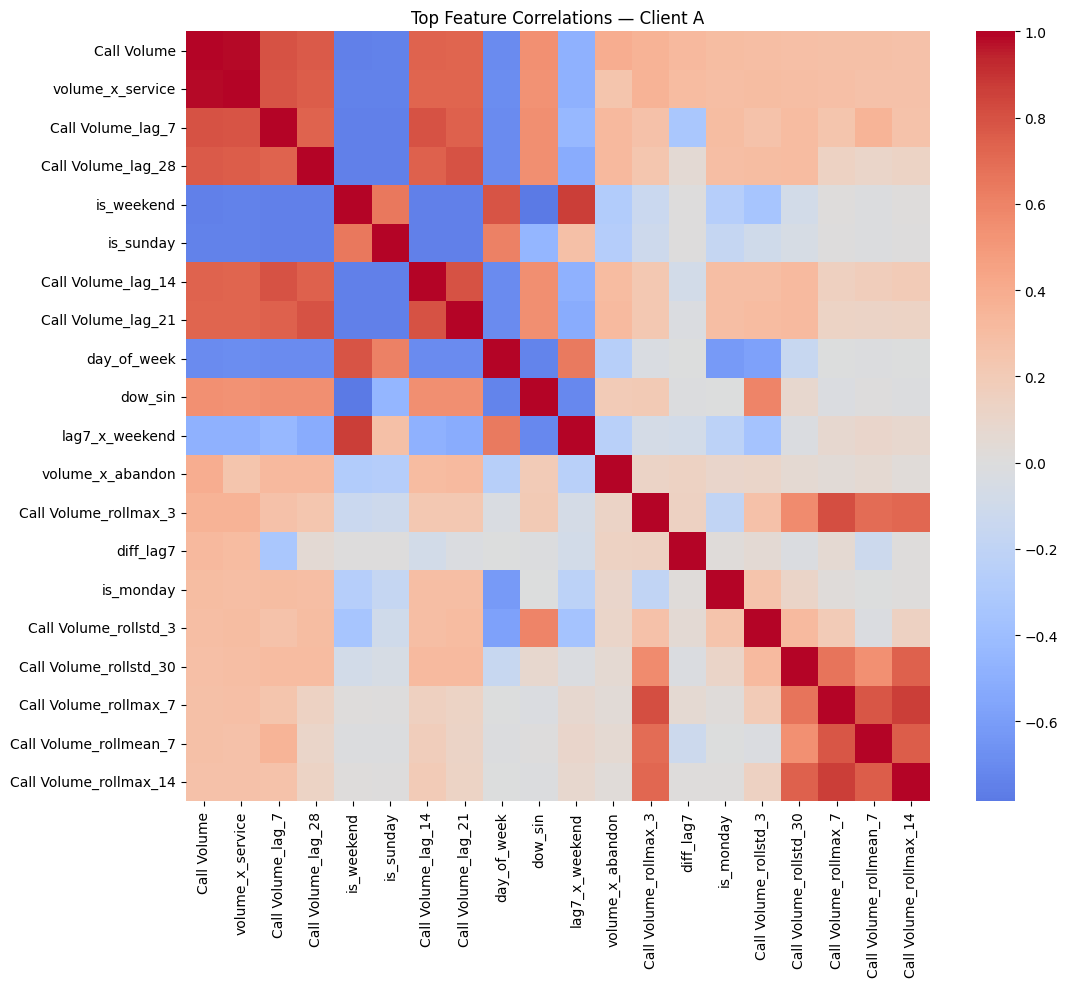

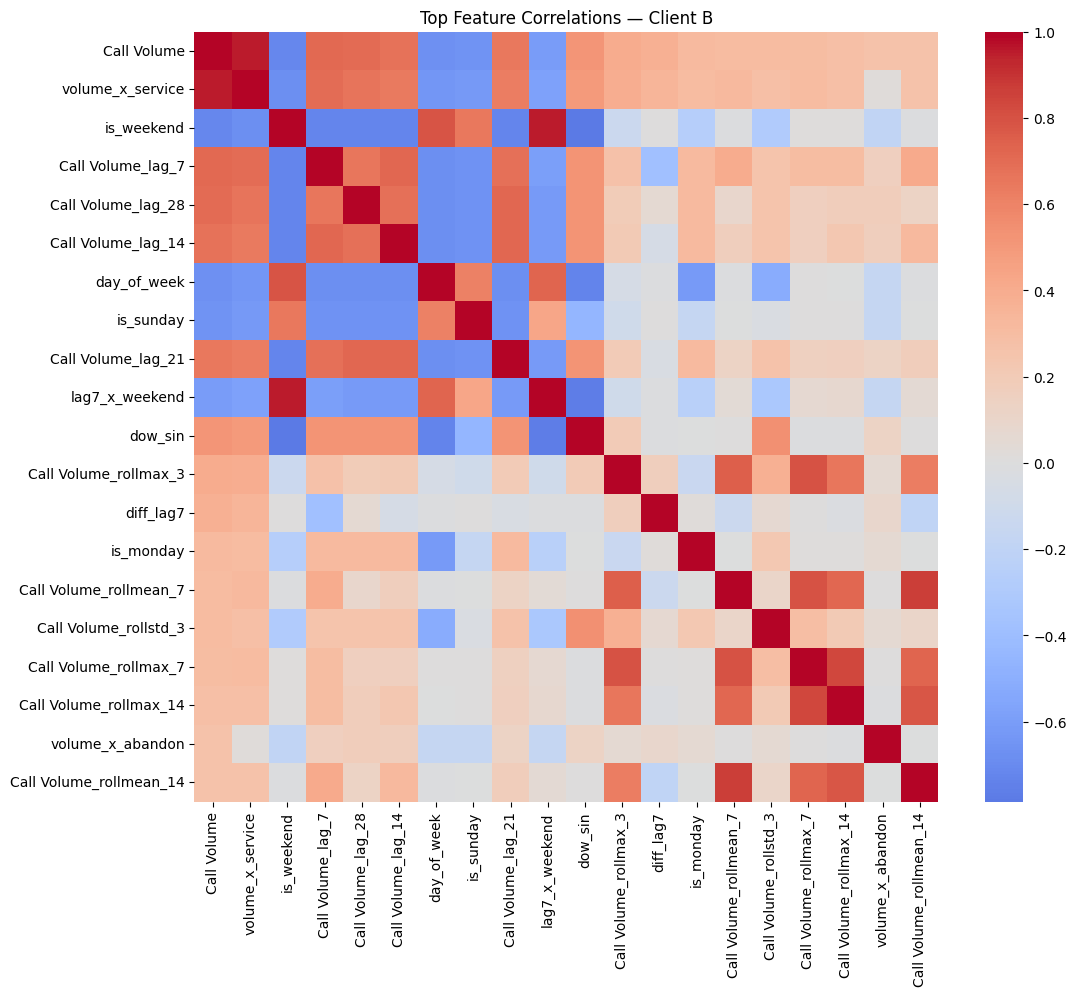

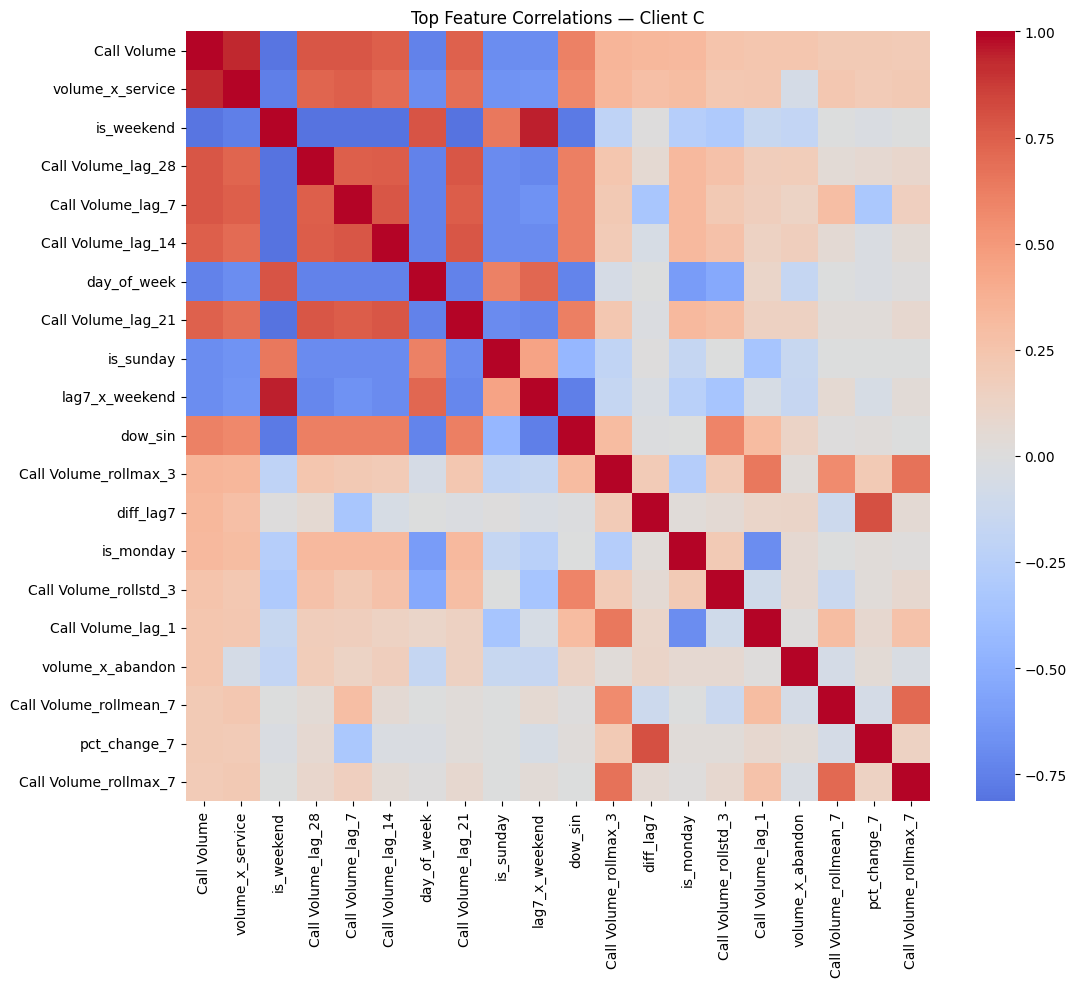

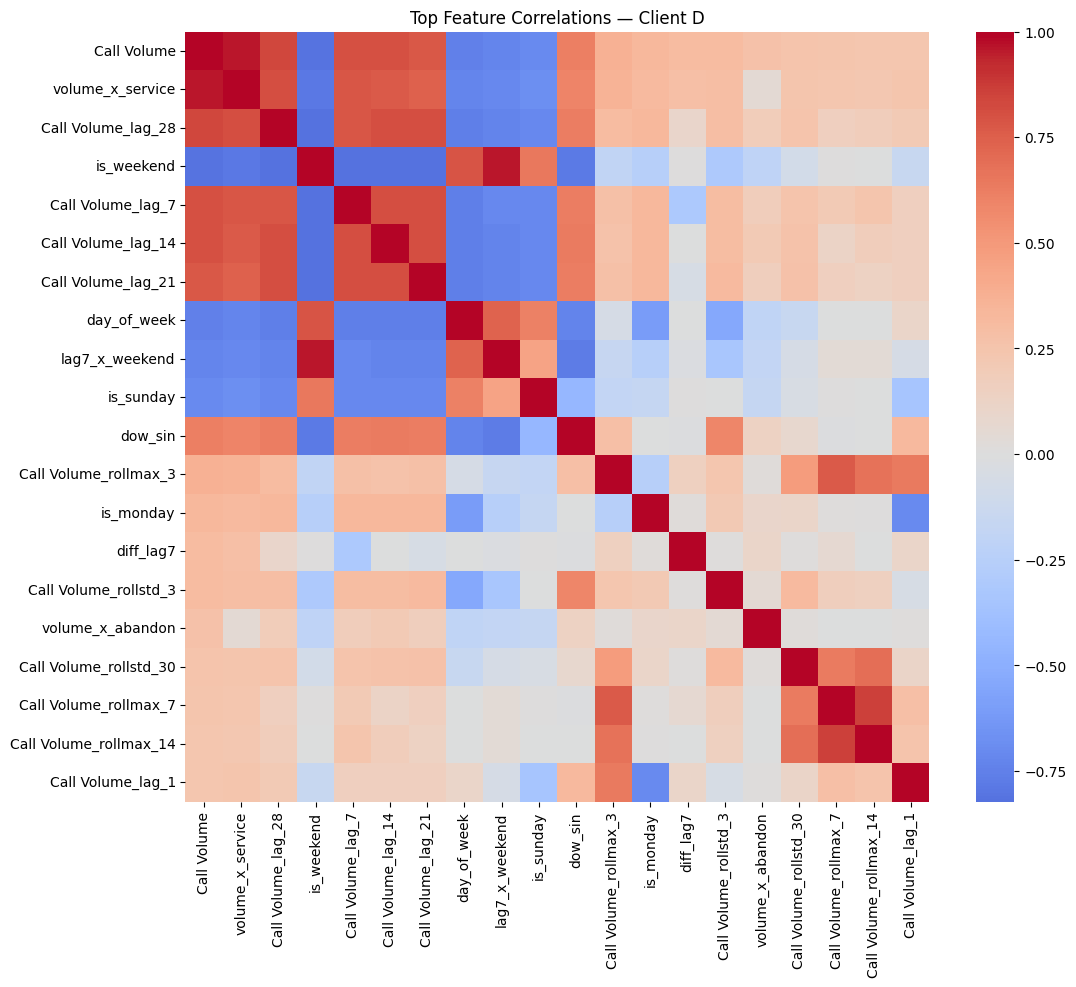

In [116]:
TARGET = "Call Volume"

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr = (
        df_client
        .corr(numeric_only=True)[TARGET]
        .abs()
        .sort_values(ascending=False)
        .head(20)
    )

    selected_cols = corr.index

    corr_matrix = df_client[
        selected_cols
    ].corr()

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        corr_matrix,
        annot=False,
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Top Feature Correlations — Client {client}"
    )

    plt.savefig(
        f"../outputs/client_{client}/top_features_corr_client.png",
        bbox_inches="tight"
    )

    plt.show()

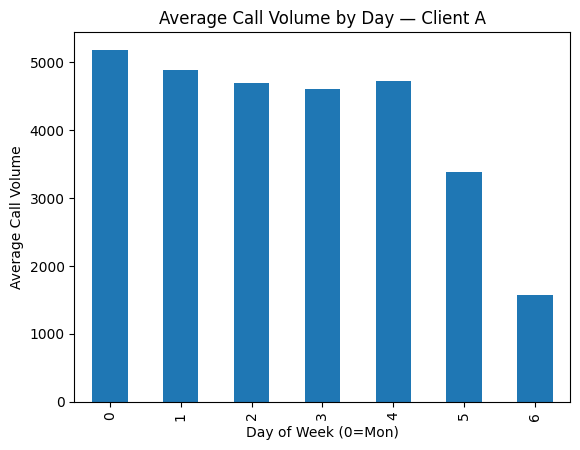

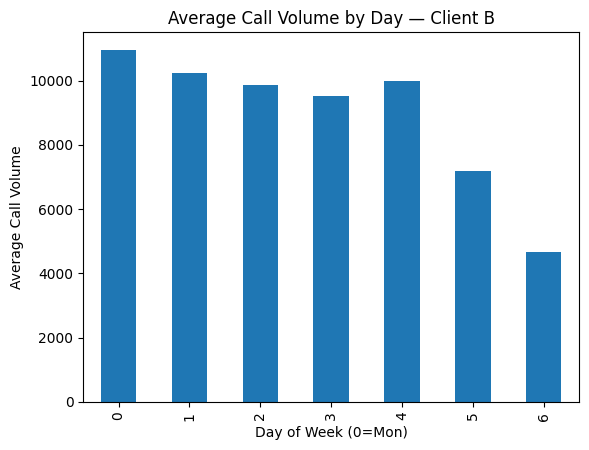

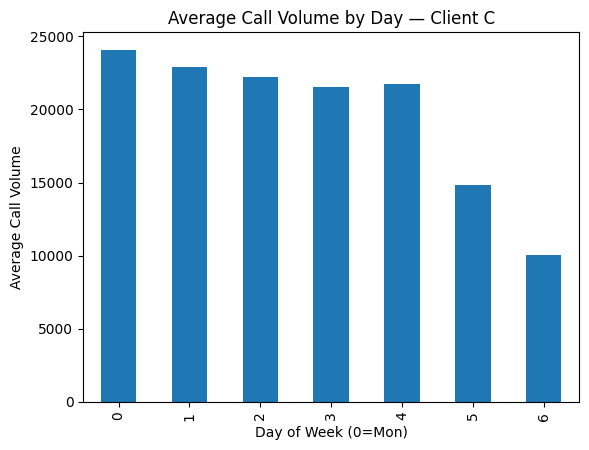

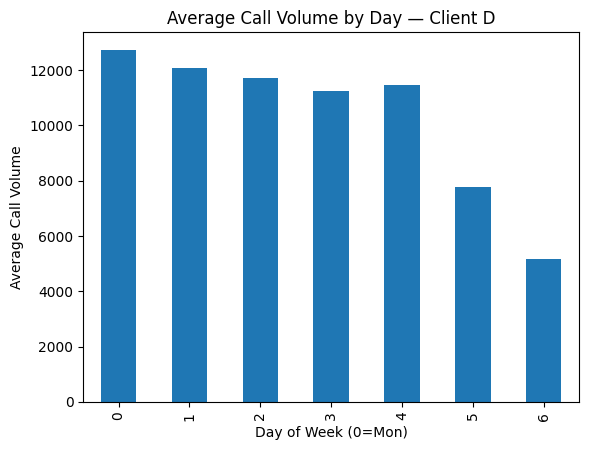

In [117]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    avg_by_dow = (
        df_client
        .groupby("day_of_week")["Call Volume"]
        .mean()
    )

    plt.figure()

    avg_by_dow.plot(kind="bar")

    plt.title(
        f"Average Call Volume by Day — Client {client}"
    )

    plt.xlabel("Day of Week (0=Mon)")
    plt.ylabel("Average Call Volume")

    plt.savefig(
        f"../outputs/client_{client}/avg_volume_by_day_of_week.png"
    )

    plt.show()

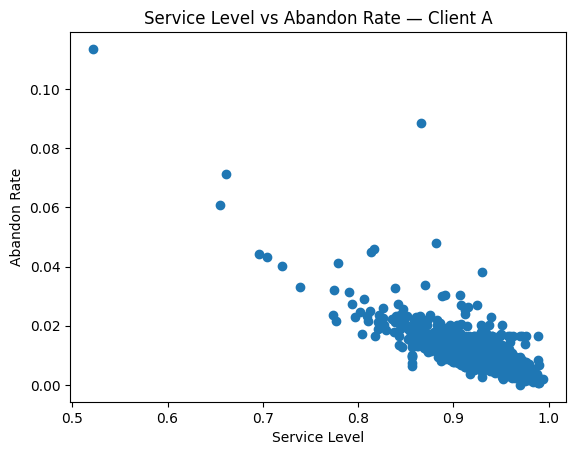

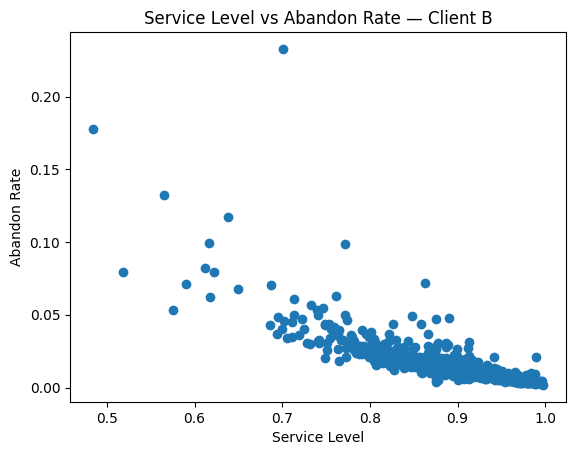

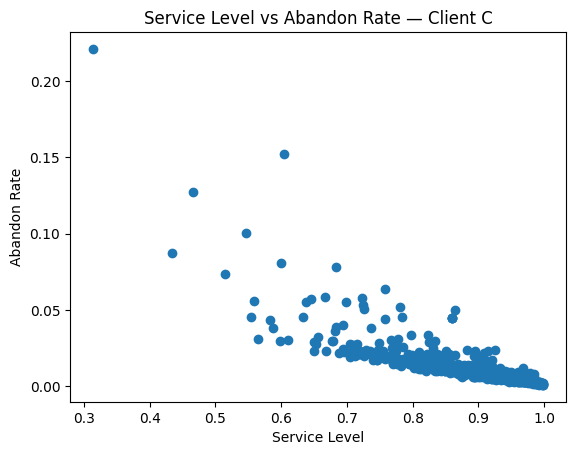

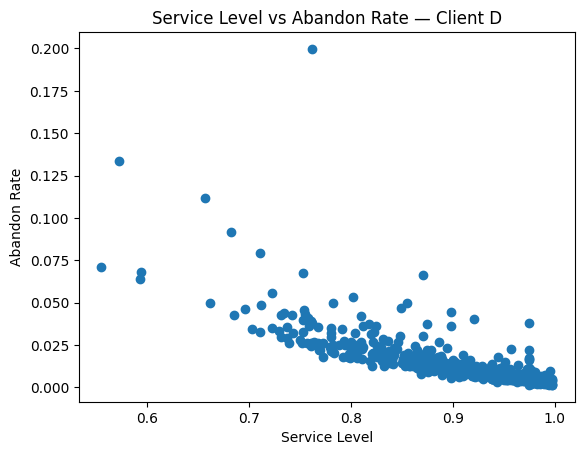

In [118]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    plt.figure()

    plt.scatter(
        df_client["Service Level"],
        df_client["Abandon Rate"]
    )

    plt.title(
        f"Service Level vs Abandon Rate — Client {client}"
    )

    plt.xlabel("Service Level")
    plt.ylabel("Abandon Rate")

    plt.savefig(
        f"../outputs/client_{client}/service_vs_abandon.png"
    )

    plt.show()

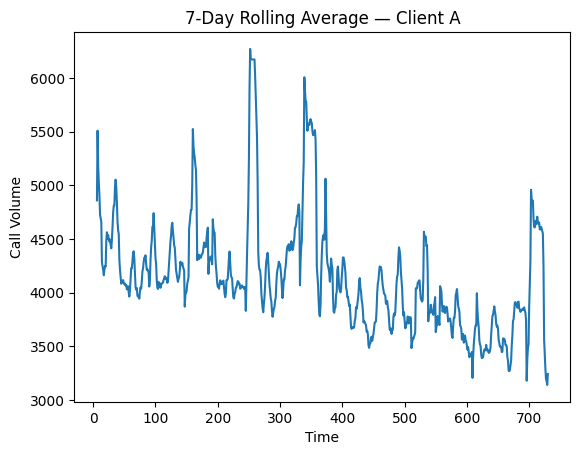

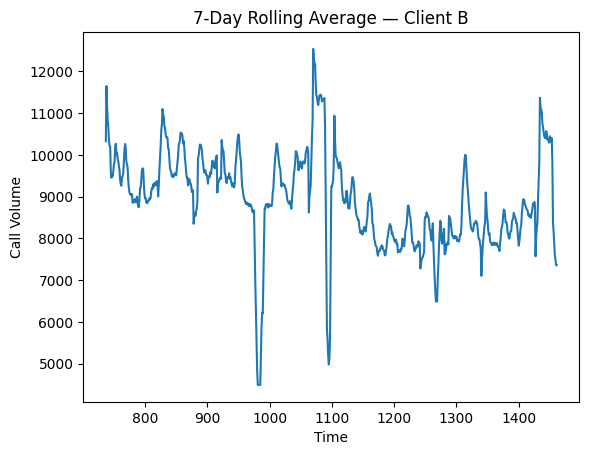

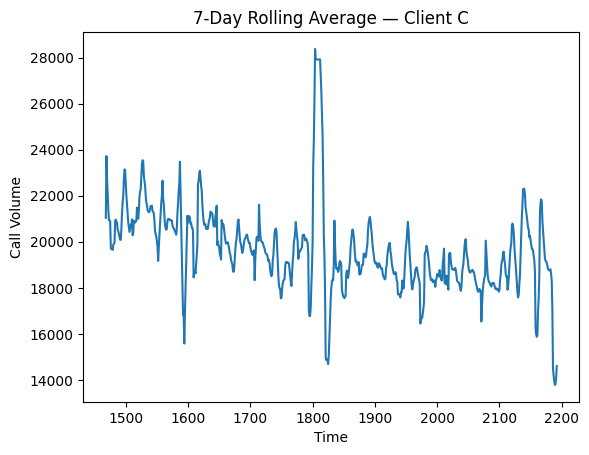

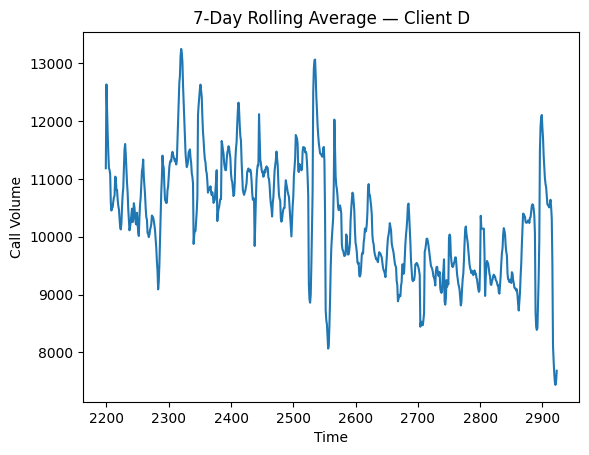

In [119]:
for client in daily_df['client'].unique():

    df_client = (
        daily_df[
            daily_df['client'] == client
        ]
        .sort_values("Date")
    )

    rolling_mean = (
        df_client["Call Volume"]
        .rolling(7)
        .mean()
    )

    plt.figure()

    rolling_mean.plot()

    plt.title(
        f"7-Day Rolling Average — Client {client}"
    )

    plt.xlabel("Time")
    plt.ylabel("Call Volume")

    plt.savefig(
        f"../outputs/client_{client}/rolling_7day_volume.png"
    )

    plt.show()

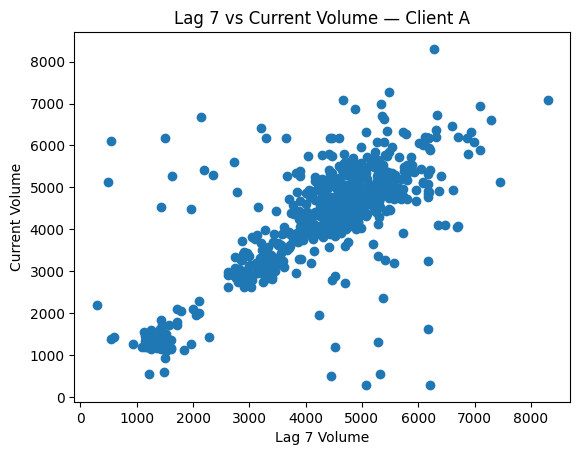

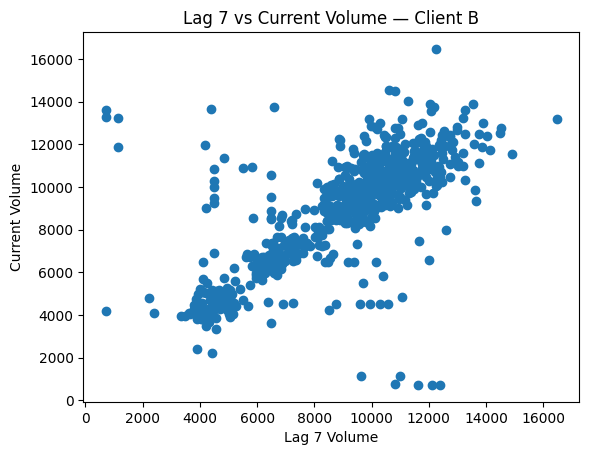

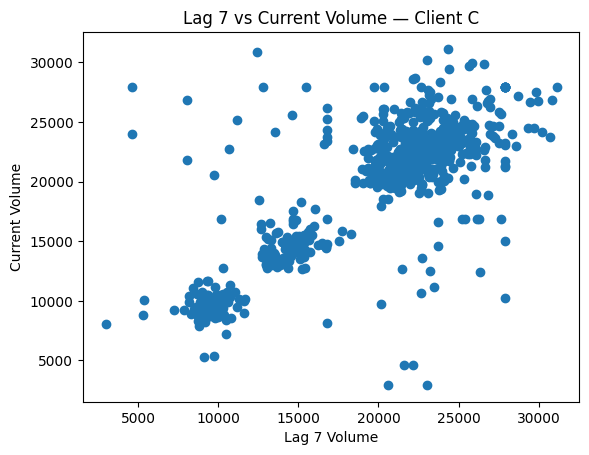

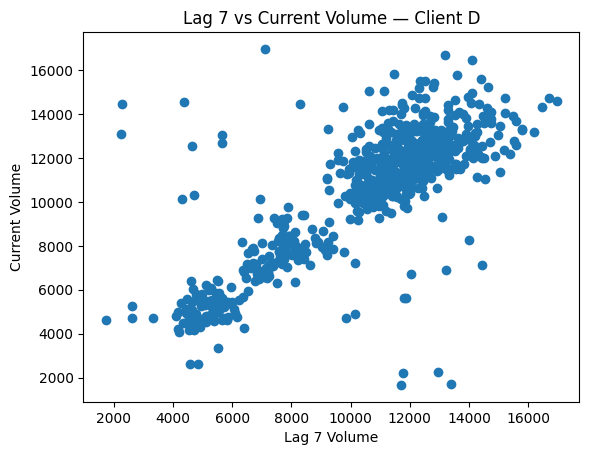

In [120]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    plt.figure()

    plt.scatter(
        df_client["Call Volume_lag_7"],
        df_client["Call Volume"]
    )

    plt.title(
        f"Lag 7 vs Current Volume — Client {client}"
    )

    plt.xlabel("Lag 7 Volume")
    plt.ylabel("Current Volume")

    plt.savefig(
        f"../outputs/client_{client}/lag7_relationship.png"
    )

    plt.show()

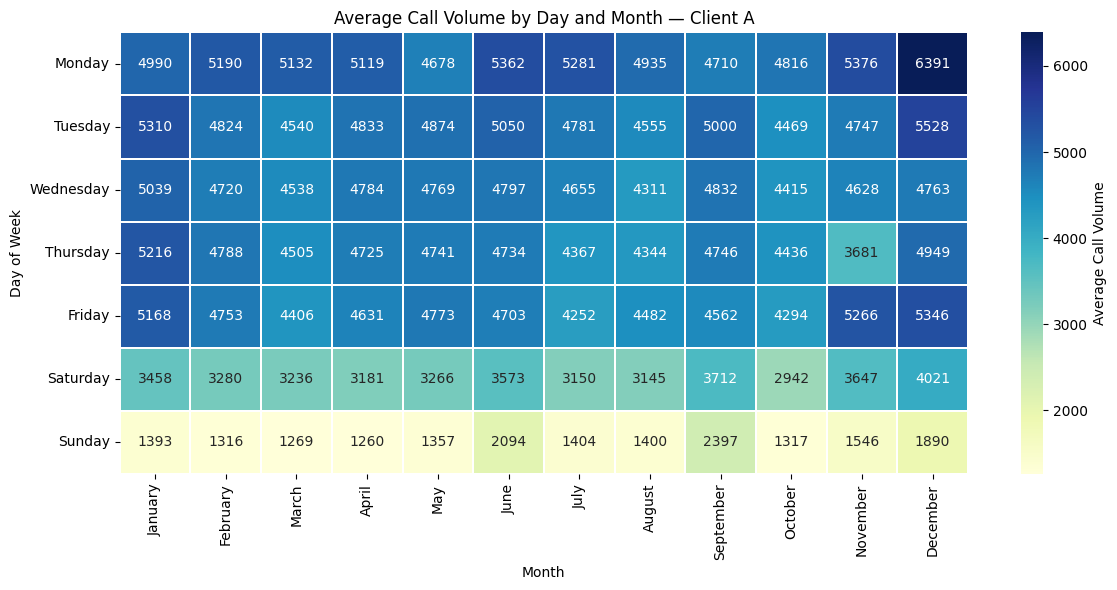

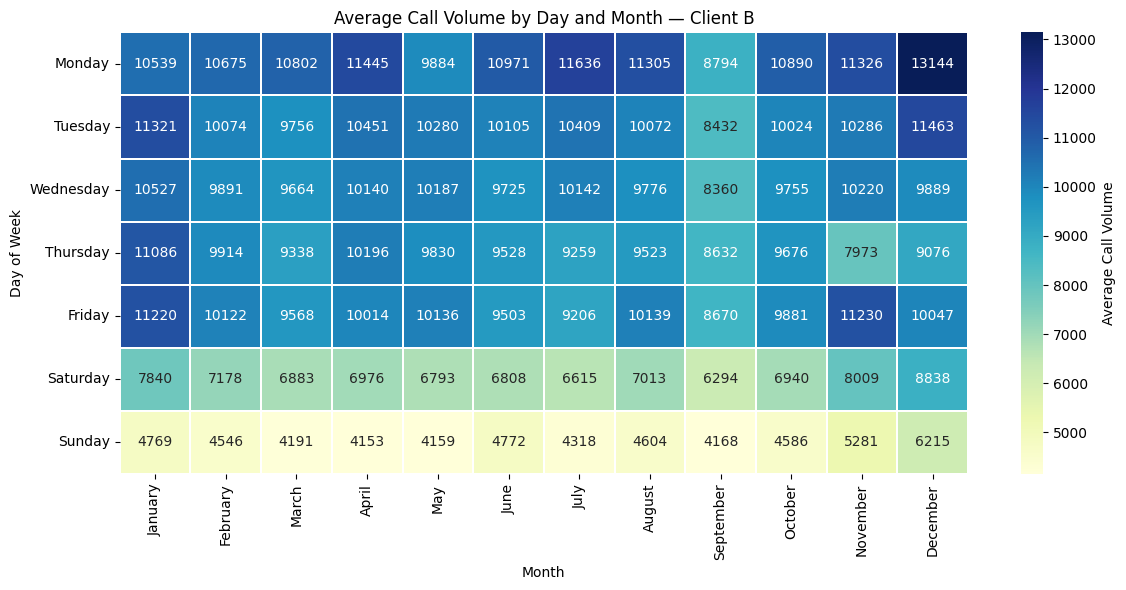

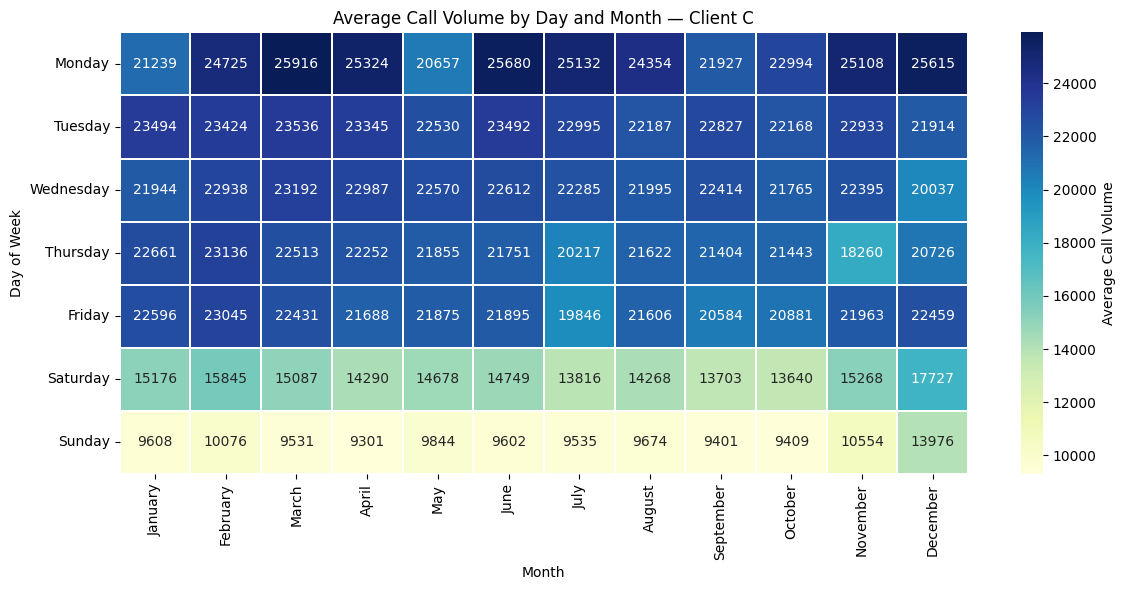

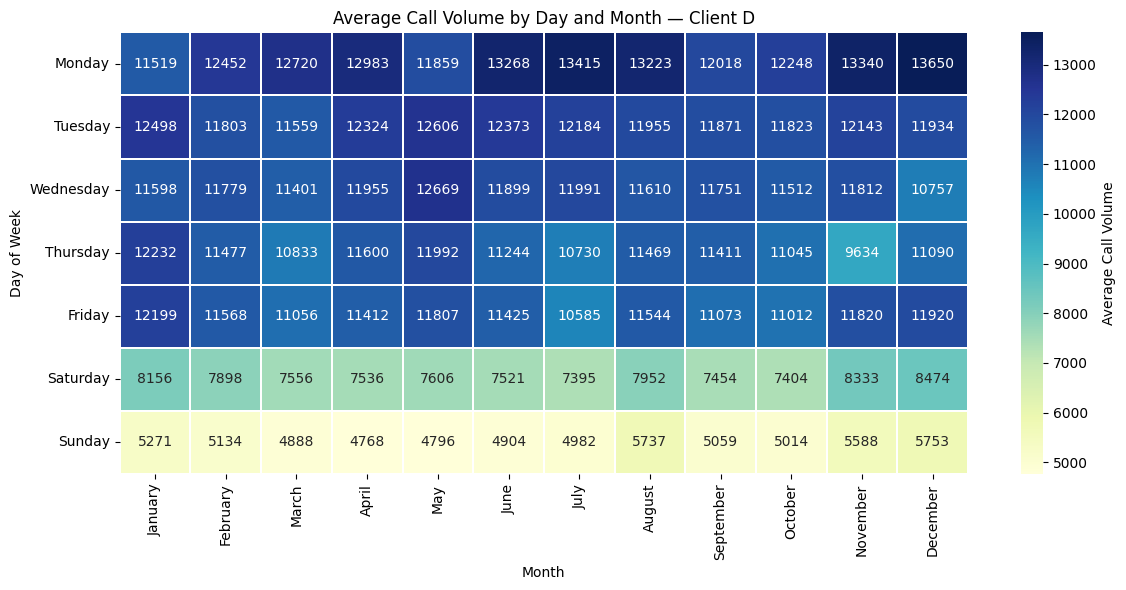

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure Date is datetime
daily_df["Date"] = pd.to_datetime(daily_df["Date"])

# Ordered labels
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

for client in daily_df["client"].unique():

    df_client = daily_df[daily_df["client"] == client].copy()

    # Pivot table: avg call volume by day_name x month_name
    heatmap_data = (
        df_client
        .groupby(["day_name", "month_name"])["Call Volume"]
        .mean()
        .unstack()
    )

    # Reorder rows and columns
    heatmap_data = heatmap_data.reindex(index=day_order, columns=month_order)

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        linewidths=0.3,
        cbar_kws={"label": "Average Call Volume"}
    )

    plt.title(f"Average Call Volume by Day and Month — Client {client}")
    plt.xlabel("Month")
    plt.ylabel("Day of Week")
    plt.tight_layout()

    output_dir = f"../outputs/client_{client}"
    os.makedirs(output_dir, exist_ok=True)

    plt.savefig(
        f"{output_dir}/heatmap_call_volume_day_month.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

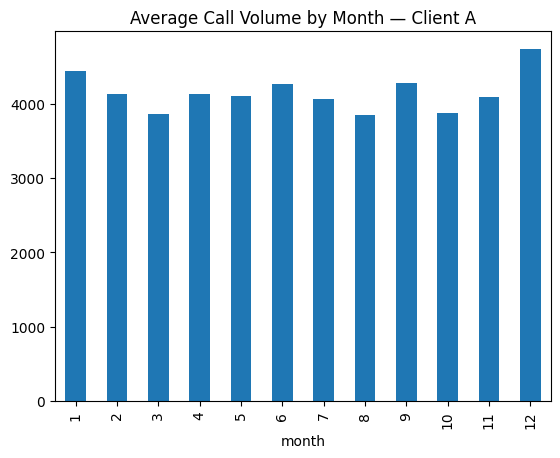

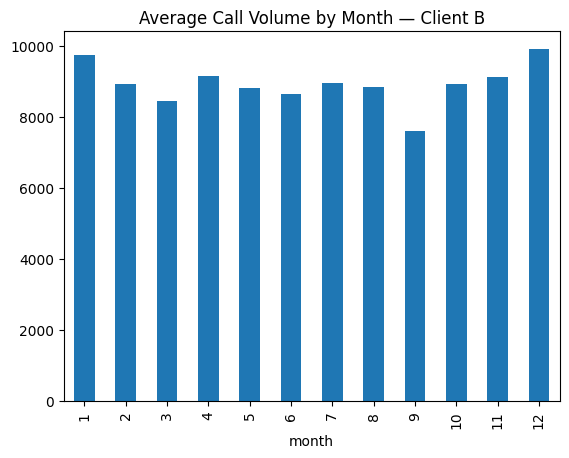

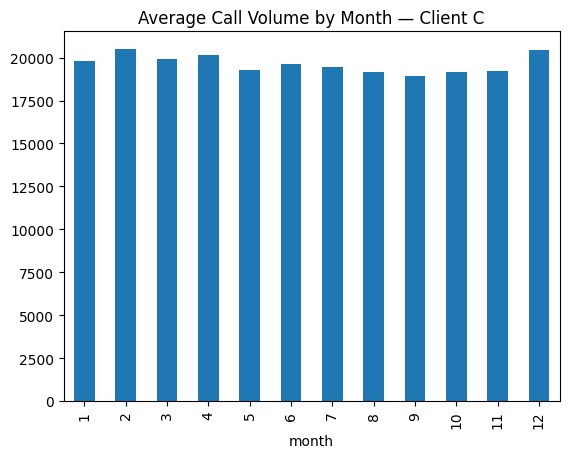

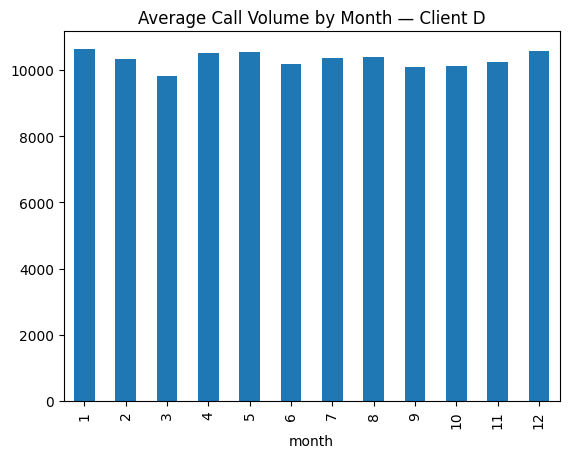

In [122]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    avg_by_month = (
        df_client
        .groupby("month")["Call Volume"]
        .mean()
    )

    plt.figure()

    avg_by_month.plot(kind="bar")

    plt.title(
        f"Average Call Volume by Month — Client {client}"
    )

    plt.savefig(
        f"../outputs/client_{client}/avg_volume_by_month.png"
    )

    plt.show()

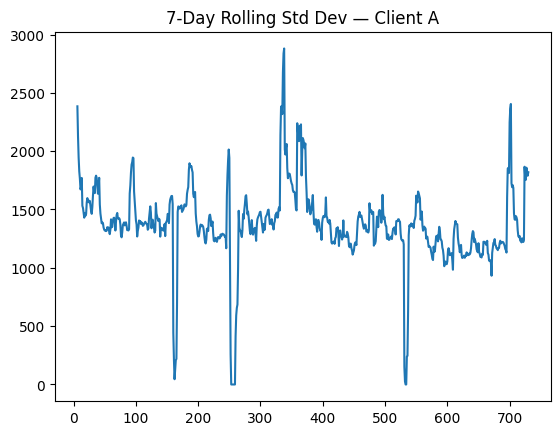

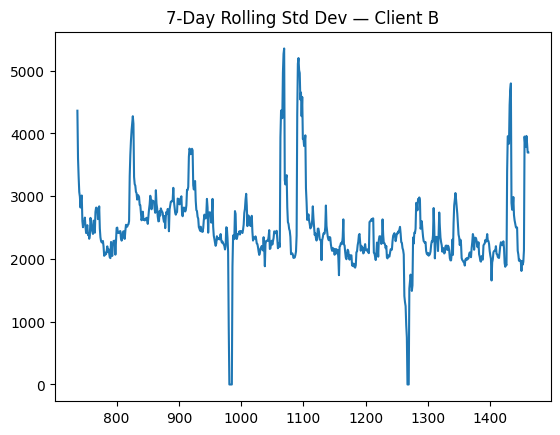

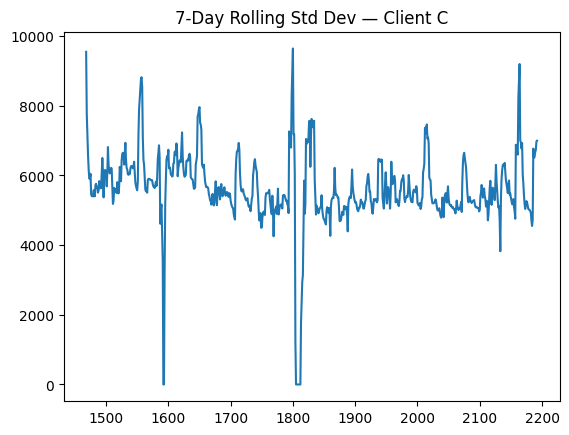

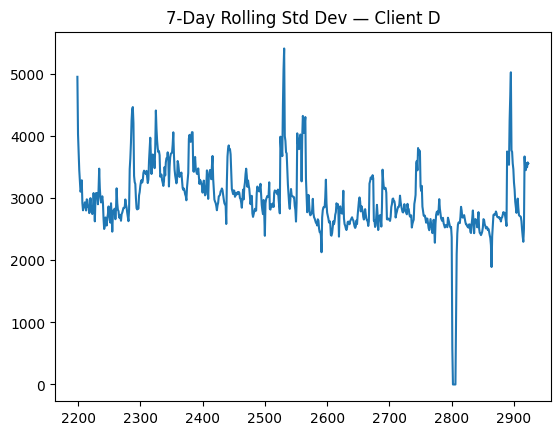

In [123]:
for client in daily_df['client'].unique():

    df_client = (
        daily_df[
            daily_df['client'] == client
        ]
        .sort_values("Date")
    )

    rolling_std = (
        df_client["Call Volume"]
        .rolling(7)
        .std()
    )

    plt.figure()

    rolling_std.plot()

    plt.title(
        f"7-Day Rolling Std Dev — Client {client}"
    )

    plt.savefig(
        f"../outputs/client_{client}/rolling_std_7.png"
    )

    plt.show()

features to maybe drop later:
- volume_x_service
- volume_x_abandon
- lag7_x_weekend
- trend_squared
- month
- quarter

In [124]:
validation_results = run_validation_checks(
    df_daily=daily_df,
    df_interval=interval_df,
    df_forecast=df_forecast
)

print_validation_summary(validation_results)


DAILY DATA VALIDATION SUMMARY
Duplicate dates: 0
Negative Call Volume rows: 0
Negative CCT rows: 0
Invalid Service Level rows: 0
Invalid Abandon Rate rows: 0
All-null columns: []
Constant columns: ['hour', 'minute', 'hour_sin', 'hour_cos', 'interval_num', 'interval_sin', 'interval_cos', 'interval_x_dow']

INTERVAL DATA VALIDATION SUMMARY
Duplicate client/date/interval rows: 0
Bad interval counts: 0
All-null columns: []
Constant columns: []

FORECAST TEMPLATE VALIDATION SUMMARY
Duplicate datetimes: 0
Duplicate interval rows: 0
Bad interval counts: 0
Invalid interval format rows: 0
All-null columns: ['Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B', 'Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C', 'Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D']
Constant columns: ['Month', 'Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', '

In [125]:
print(daily_df.shape)
print(interval_df.shape)
print(staffing_df.shape)

(2924, 64)
(17102, 41)
(365, 5)


In [126]:
# =========================================================
# Save cleaned data for downstream notebooks
# =========================================================

# Create path relative to notebooks folder
processed_path = Path("../data/processed")

# Make folder if it doesn't exist
processed_path.mkdir(parents=True, exist_ok=True)

# -------------------------
# Save datasets
# -------------------------

# Daily data
if "daily_df" in globals():
    daily_df.to_csv(
        processed_path / "daily_df.csv",
        index=False
    )
    print("Saved daily_df.csv")

# Interval data
if "interval_df" in globals():
    interval_df.to_csv(
        processed_path / "interval_df.csv",
        index=False
    )
    print("Saved interval_df.csv")

# Staffing data
if "staffing_df" in globals():
    staffing_df.to_csv(
        processed_path / "staffing_df.csv",
        index=False
    )
    print("Saved staffing_df.csv")

print("\nAll processed datasets saved to:")
print(processed_path.resolve())

Saved daily_df.csv
Saved interval_df.csv
Saved staffing_df.csv

All processed datasets saved to:
/Users/trustanprice/Desktop/Personal/illinois-datathon-team015/data/processed
